In [69]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set default styles for our plots
sns.set_theme()

## 1. Data Preparation
We'll define a simple dataset representing years of experience and the corresponding salary.

In [6]:
X = np.array([1 , 3, 4, 6, 7]) # Input feature: years of experience
y = np.array([15,35,45,65,75]) # Target value: salary (in thousands)


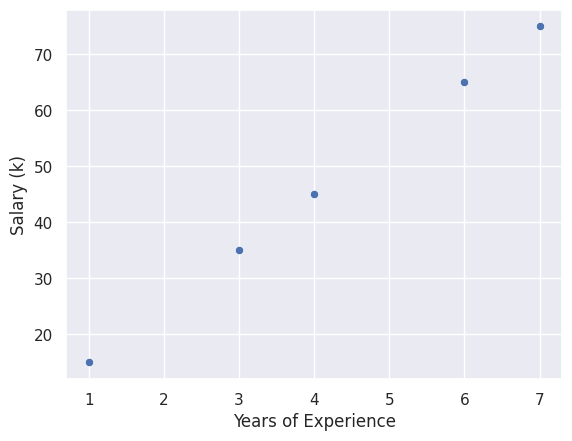

In [7]:
# Visualize the relationship between experience and salary
sns.scatterplot(x=X, y=y)
plt.xlabel("Years of Experience")
plt.ylabel("Salary (k)")
plt.show()

## 2. Prediction Function
The linear model is defined as $f(x) = wx + b$. Here we create a function to generate predictions for our dataset.

In [8]:
def make_prediction(X,y,w,b):
  m=X.shape[0]
  prediction=np.zeros((m,)) # Initialize an array to store results
  for i in range(m):        #List can be use also,but for a small dataset numpy array is better considering memory allocation
    prediction[i]= w*X[i] + b

  return prediction




Predictions (0,0): [0. 0. 0. 0. 0.]


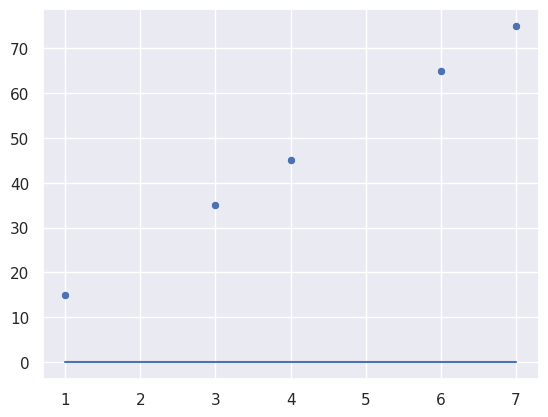

In [9]:
pred=make_prediction(X,y,0,0)
print(f"Predictions (0,0): {pred}")
sns.scatterplot(x=X, y=y)
plt.plot(X, pred, label='Initial model (w=0, b=0)')

[1. 3. 4. 6. 7.]


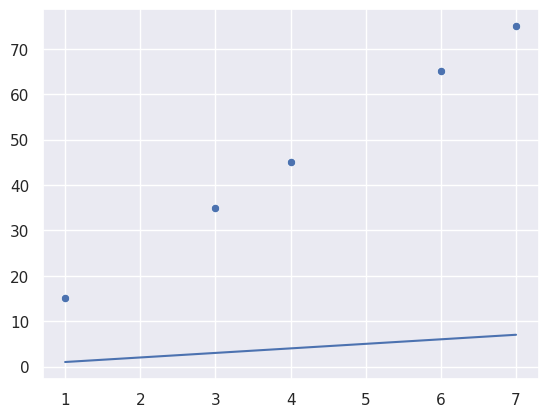

In [10]:
predictions = make_prediction(X,y,w=1,b=0)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

[15. 35. 45. 65. 75.]


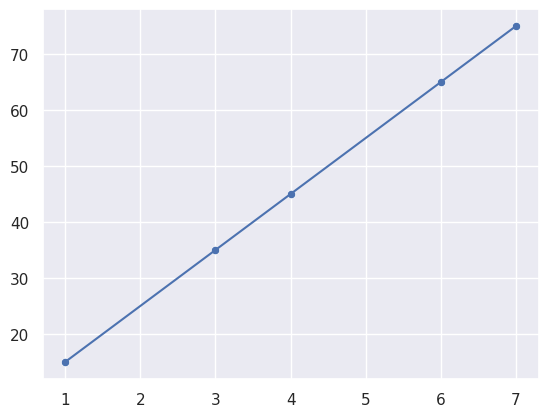

In [11]:
predictions = make_prediction(X,y,w=10,b=5)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

## 3. Cost Function
To evaluate how well our model fits, we calculate the 'Cost' (Mean Squared Error). A lower cost means a better fit.
##Cost= {Sumation of(y'-y)^2} /m

In [29]:
def cost_function(X,y,w,b):
  m=X.shape[0]
  prediction=np.zeros((m,))
  cost=0.0
  for i in range(m):
    prediction[i]= w*X[i] + b
    error=prediction[i]-y[i]
    error_sq=error**2
    cost=cost+error_sq
  cost=cost/m
  return cost

In [30]:
error=cost_function(X,y,1,0)
print(error)

2201.2


Text(0.5, 1.0, 'Cost:2201.2 for w=1 and b=0')

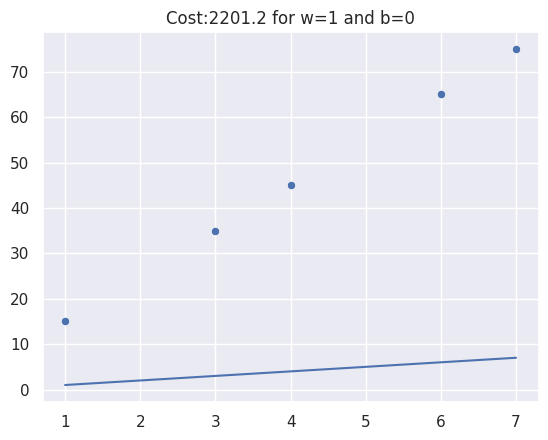

In [31]:
w=1
b=0
# Calculate predictions and evaluate cost manually
sns.scatterplot(x=X, y=y)
plt.plot(X,make_prediction(X,y,w=w,b=b),label='Initial model (w=0, b=0)')
plt.title(f"Cost:{cost_function(X,y,w=w,b=b)} for w={w} and b={b}")

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 0.0, for w =10.0 and b=5.0')

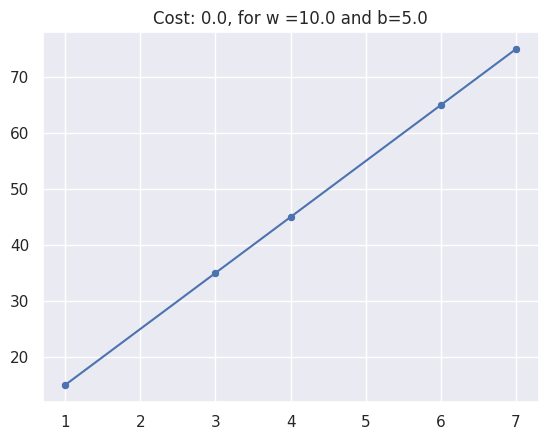

In [32]:
w= 10.0
b= 5.0

predictions = make_prediction(X,y,w=w,b=b)
print(predictions)

sns.scatterplot(x= X , y = y)
plt.plot(X ,predictions)

plt.title(f"Cost: {cost_function(X,y,w=w,b=b)}, for w ={w} and b={b}")

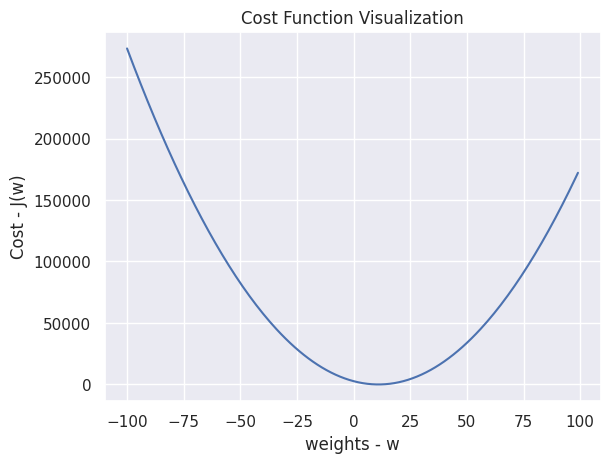

In [33]:
cost_his= []
w_range= []
for i in range(-100,100):
  cost=cost_function(X,y,w=i,b=0)
  w_range.append(i)
  cost_his.append(cost)

plt.plot(w_range,cost_his)
plt.xlabel("weights - w")
plt.ylabel("Cost - J(w)")
plt.title("Cost Function Visualization")
plt.show()

## 5. Gradient Descent
Instead of guessing, we use the gradient (slope) to update $w$ and $b$ automatically until the cost is minimized.

In [51]:
def calculate_gradient(X,y,w,b):
  m=X.shape[0]
  dj_dw=0.0
  dj_db=0.0

  for i in range(m):
    prediction= w * X[i] + b
    error= prediction - y[i]
    dj_dw= dj_dw + (error * X[i])
    dj_db= dj_db + error
  dj_dw=dj_dw/m
  dj_db=dj_db/m

  return dj_dw,dj_db



In [87]:
gradient=calculate_gradient(X,y,w=3,b=0)
print(gradient)


(np.float64(-176.4), np.float64(-34.4))


In [88]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01):
  w=w_input
  b=b_input
  cost_memo=[]
  iteration=[]
  for i in range(max_iter):
    dj_dw,dj_db=calculate_gradient(X,y,w,b)
    w = w - alpha * dj_dw
    b = b - alpha * dj_db
    cost=cost_function(X,y,w,b)
    cost_memo.append(cost)
    iteration.append(i)
    if i % 100 == 0:
      print(f"Iteration {i}: Cost:{cost:0.4f}, w={w:0.4f}, b={b:0.4f}")
  return w,b,cost_memo,iteration #results are store here, if we don't do the return step, the final output will not store


In [89]:
w_f,b_f,cost_memo,iter=gradient_descent(X,y,w_input=0,b_input=0,max_iter=10000,alpha=0.01)
print(w,b)

#Conventionally: w_input=0,b_input=0


Iteration 0: Cost:1580.7433, w=2.4300, b=0.4700
Iteration 100: Cost:1.2240, w=10.4659, b=2.5593
Iteration 200: Cost:0.8230, w=10.3821, b=2.9986
Iteration 300: Cost:0.5534, w=10.3133, b=3.3588
Iteration 400: Cost:0.3721, w=10.2569, b=3.6542
Iteration 500: Cost:0.2502, w=10.2107, b=3.8965
Iteration 600: Cost:0.1683, w=10.1727, b=4.0951
Iteration 700: Cost:0.1131, w=10.1416, b=4.2580
Iteration 800: Cost:0.0761, w=10.1162, b=4.3915
Iteration 900: Cost:0.0512, w=10.0952, b=4.5010
Iteration 1000: Cost:0.0344, w=10.0781, b=4.5909
Iteration 1100: Cost:0.0231, w=10.0640, b=4.6645
Iteration 1200: Cost:0.0156, w=10.0525, b=4.7249
Iteration 1300: Cost:0.0105, w=10.0431, b=4.7744
Iteration 1400: Cost:0.0070, w=10.0353, b=4.8150
Iteration 1500: Cost:0.0047, w=10.0290, b=4.8483
Iteration 1600: Cost:0.0032, w=10.0237, b=4.8756
Iteration 1700: Cost:0.0021, w=10.0195, b=4.8980
Iteration 1800: Cost:0.0014, w=10.0160, b=4.9164
Iteration 1900: Cost:0.0010, w=10.0131, b=4.9314
Iteration 2000: Cost:0.0006, w

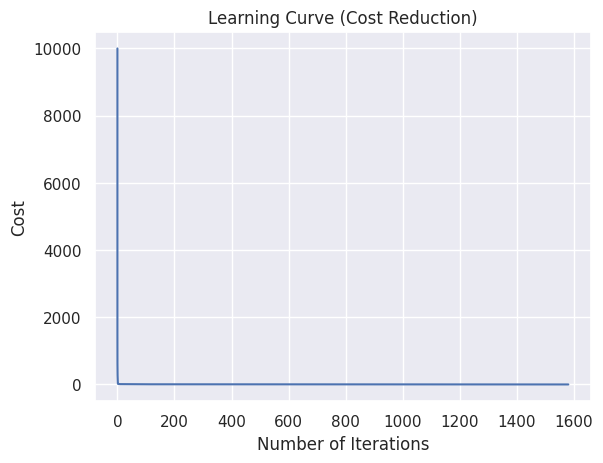

In [82]:
plt.plot(iter,cost_memo)
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

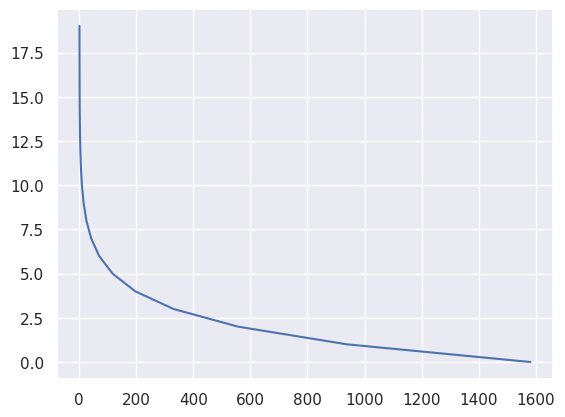

In [80]:
plt.plot(iter[:20],cost_memo[:20])
plt.xlabel("Number of Iterations")
plt.ylabel("Cost")
plt.title("Learning Curve (Cost Reduction)")
plt.show()

Optimized w: 10.0000, b: 5.0000


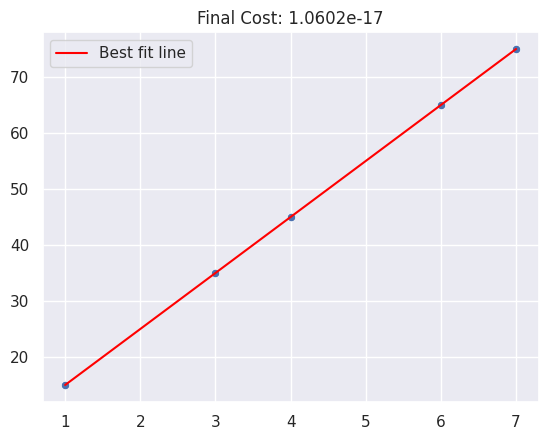

In [86]:
print(f"Optimized w: {w_f:0.4f}, b: {b_f:0.4f}")

# Get final predictions based on optimized parameters
final_preds = make_prediction(X, y, w=w_f, b=b_f)

# Visualize the final best-fit line
sns.scatterplot(x=X, y=y)
plt.plot(X, final_preds, color='red', label='Best fit line')
plt.title(f"Final Cost: {cost_function(X, y, w_f, b_f):0.4e}")
plt.legend()
plt.show()